# Whisper-small — fine-tuning encoder

**Модель:** Whisper-small encoder (верхние N слоёв разморожены) + classification head

```
Whisper encoder (12 слоёв)
  └── Нижние 8 слоёв: заморожены
  └── Верхние 4 слоя: обучаемые
  ↓
Mean pooling → Dropout → Linear(384, 2)
```

In [1]:
import sys
from pathlib import Path
import numpy as np
import time
import mlflow
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1
from transformers import WhisperModel, WhisperProcessor
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv
from shared.mlflow_utils import start_run, log_epoch, log_artifact_if_exists

train_utils.set_seed(config.RANDOM_STATE)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

I0000 00:00:1778074202.989727    3733 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Device: cuda:0


In [2]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_holdout_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train,  paths_val  = paths_trainval[idx_tr],  paths_trainval[idx_val]
labels_train, labels_val = labels_trainval[idx_tr], labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]

print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")

Train: 1934, Val: 425, Test: 417


In [3]:
MODEL_ID = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(MODEL_ID)

class WhisperDataset(Dataset):
    def __init__(self, paths, labels, letters, augment=False):
        self.paths = paths
        self.labels = labels
        self.letters = letters
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        y, sr = data_utils.load_audio(self.paths[i], sr=16000, max_sec=30.0)
        feats = processor.feature_extractor(
            y, sampling_rate=16000, return_tensors="np"
        ).input_features[0]  # (80, 3000)
        if self.augment:
            feats = data_utils.augment_mel_spectrogram(feats)
        return (
            torch.from_numpy(feats).float(),
            torch.from_numpy(self.letters[i]).float(),
            int(self.labels[i]),
        )

BATCH_SIZE = 8
train_loader = DataLoader(
    WhisperDataset(paths_train, labels_train, letters_train, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    WhisperDataset(paths_val, labels_val, letters_val, augment=False),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    WhisperDataset(paths_test, labels_test, letters_test, augment=False),
    batch_size=BATCH_SIZE, shuffle=False
)

In [4]:
N_UNFREEZE = 4
EMBED_DIM  = 768
DROPOUT    = 0.3
N_EPOCHS   = 30

class WhisperClassifier(nn.Module):
    def __init__(self, whisper_model, n_letters=0, dropout=DROPOUT, n_unfreeze=N_UNFREEZE):
        super().__init__()
        self.encoder = whisper_model.encoder
        self.n_letters = n_letters

        for p in self.encoder.parameters():
            p.requires_grad = False

        n_layers = len(self.encoder.layers)
        for layer in self.encoder.layers[n_layers - n_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True
        for p in self.encoder.layer_norm.parameters():
            p.requires_grad = True

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(EMBED_DIM + n_letters, 2)

        n_frozen = sum(not p.requires_grad for p in self.encoder.parameters())
        n_train  = sum(p.requires_grad for p in self.parameters())
        print(f"Encoder параметров замороженных: {n_frozen}")
        print(f"Всего обучаемых параметров: {n_train}")

    def forward(self, input_features, letters=None):
        hidden = self.encoder(input_features).last_hidden_state
        pooled = hidden.mean(dim=1)
        pooled = self.dropout(pooled)
        if self.n_letters > 0 and letters is not None:
            pooled = torch.cat([pooled, letters], dim=1)
        return self.head(pooled)


whisper_model = WhisperModel.from_pretrained(MODEL_ID)
n_letters = letters_train.shape[1]
model = WhisperClassifier(whisper_model, n_letters=n_letters, n_unfreeze=N_UNFREEZE).to(device)
n_params_total     = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {n_params_total:,}  |  Обучаемых: {n_params_trainable:,}")

Encoder параметров замороженных: 125
Всего обучаемых параметров: 64

Всего параметров: 88,155,666  |  Обучаемых: 28,351,506


Epoch 1/30  loss=0.6441  val_f1_bad=0.6685  thr=0.44  lr=2.50e-06
Epoch 2/30  loss=0.5672  val_f1_bad=0.7248  thr=0.48  lr=5.00e-06
Epoch 3/30  loss=0.4924  val_f1_bad=0.7562  thr=0.54  lr=5.00e-06
Epoch 4/30  loss=0.4385  val_f1_bad=0.7733  thr=0.46  lr=5.00e-06
Epoch 5/30  loss=0.3893  val_f1_bad=0.7698  thr=0.51  lr=5.00e-06
Epoch 6/30  loss=0.3194  val_f1_bad=0.7833  thr=0.77  lr=5.00e-06
Epoch 7/30  loss=0.2764  val_f1_bad=0.7801  thr=0.69  lr=5.00e-06
Epoch 8/30  loss=0.2487  val_f1_bad=0.7554  thr=0.63  lr=5.00e-06
Epoch 9/30  loss=0.1829  val_f1_bad=0.7681  thr=0.59  lr=5.00e-06
Epoch 10/30  loss=0.1594  val_f1_bad=0.7698  thr=0.66  lr=5.00e-06
Epoch 11/30  loss=0.1332  val_f1_bad=0.7586  thr=0.21  lr=5.00e-06
Epoch 12/30  loss=0.1124  val_f1_bad=0.7491  thr=0.10  lr=2.50e-06
Epoch 13/30  loss=0.0666  val_f1_bad=0.7333  thr=0.19  lr=2.50e-06
Epoch 14/30  loss=0.0779  val_f1_bad=0.7294  thr=0.65  lr=2.50e-06
Epoch 15/30  loss=0.0500  val_f1_bad=0.7435  thr=0.10  lr=2.50e-06
Epoc

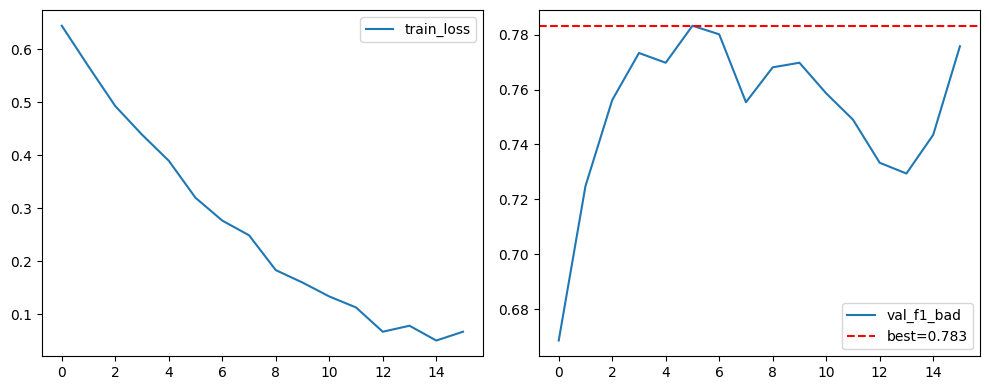

In [5]:
import json
with start_run("exp_whisper_finetune", group="04_pretrained_finetuned"):

    mlflow.log_params({
        "encoder":          MODEL_ID,
        "n_unfreeze":       N_UNFREEZE,
        "embed_dim":        EMBED_DIM,
        "dropout":          DROPOUT,
        "n_epochs":         N_EPOCHS,
        "batch_size":       BATCH_SIZE,
        "lr_encoder":       5e-6,
        "lr_head":          1e-4,
        "lr_warmup_epochs": 2,
        "augment":          "SpecAugment",
        "class_weight":     "balanced",
        "monitor_metric":   "val_f1_bad_opt_thr",
        "early_stopping_patience": config.EARLY_STOPPING_PATIENCE,
        "num_params_trainable": n_params_trainable,
    })

    weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))

    encoder_params = [p for n, p in model.named_parameters()
                      if p.requires_grad and 'head' not in n]
    head_params    = list(model.head.parameters())
    TARGET_LR_ENCODER = 5e-6
    optimizer = torch.optim.AdamW([
        {"params": encoder_params, "lr": TARGET_LR_ENCODER, "weight_decay": 1e-3},
        {"params": head_params,    "lr": 1e-4,              "weight_decay": 1e-4},
    ])
    scheduler = train_utils.get_lr_scheduler(optimizer)
    early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
    best_ckpt = exp_dir / "best_ckpt.pt"
    best_f1 = -1.0

    N_WARMUP_EPOCHS = 2
    warmup_steps = N_WARMUP_EPOCHS * len(train_loader)

    def eval_loader(loader):
        model.eval()
        logits_list, true_list = [], []
        with torch.no_grad():
            for feats, letters, y in loader:
                logits = model(feats.to(device), letters.to(device))
                logits_list.append(logits.cpu().numpy())
                true_list.extend(y.tolist())
        logits = np.concatenate(logits_list)
        proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
        return proba, np.array(true_list)

    train_losses, val_f1s = [], []
    t0 = time.perf_counter()
    global_step = 0

    for epoch in range(N_EPOCHS):
        model.train()
        losses = []
        for feats, letters, y in train_loader:
            # Fix 3: linear LR warmup for encoder (step 0 → TARGET_LR_ENCODER)
            if global_step < warmup_steps:
                optimizer.param_groups[0]["lr"] = TARGET_LR_ENCODER * (global_step + 1) / warmup_steps

            feats, letters, y = feats.to(device), letters.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(feats, letters), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
            optimizer.step()
            global_step += 1
            losses.append(loss.item())
        train_loss = np.mean(losses)
        train_losses.append(train_loss)

        val_proba, val_true = eval_loader(val_loader)
        # Fix 2: выбор чекпоинта по val_f1_bad с оптимальным порогом
        _opt_thr = find_optimal_threshold(val_true, val_proba)
        val_f1 = _f1(val_true, (val_proba >= _opt_thr).astype(int),
                     pos_label=config.CLASS_BAD, average="binary")
        val_f1s.append(val_f1)

        log_epoch(epoch, train_loss=train_loss, val_f1_bad=val_f1,
                  lr=optimizer.param_groups[0]["lr"])

        if val_f1 > best_f1:
            best_f1 = val_f1
            train_utils.save_best_checkpoint(model, best_ckpt)
        # Fix 3: ReduceLROnPlateau только после прогрева
        if global_step > warmup_steps:
            scheduler.step(val_f1)
        print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  "
              f"val_f1_bad={val_f1:.4f}  thr={_opt_thr:.2f}  "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")
        if early_stopping.step(val_f1):
            print(f"Early stopping на эпохе {epoch+1}")
            break

    train_time_sec = time.perf_counter() - t0
    train_utils.load_best_checkpoint(model, best_ckpt, device)
    print(f"\nОбучение: {train_time_sec:.1f} с | best val_f1_bad={best_f1:.4f}")

    val_proba, val_true = eval_loader(val_loader)
    optimal_threshold = find_optimal_threshold(val_true, val_proba)
    json.dump({"threshold": float(optimal_threshold)}, open(exp_dir / "threshold.json", "w"))
    print(f"Оптимальный порог: {optimal_threshold:.2f}")

    test_proba, test_true = eval_loader(test_loader)
    test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)

    import pandas as pd
    pd.DataFrame({
        "path":    paths_test,
        "y_true":  test_true,
        "y_pred":  (test_proba >= optimal_threshold).astype(int),
        "y_proba": test_proba,
    }).to_csv(exp_dir / "test_predictions.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
    axes[1].plot(val_f1s, label="val_f1_bad")
    axes[1].axhline(best_f1, color="r", linestyle="--", label=f"best={best_f1:.3f}")
    axes[1].legend()
    plt.tight_layout()
    fig.savefig(exp_dir / "training_curves.png", dpi=120)
    plt.show()

    save_result_csv(
        exp_dir=exp_dir,
        experiment_id="exp_whisper_finetune",
        experiment_name=f"Whisper-small fine-tuning (верхние {N_UNFREEZE} слоя)",
        model="WhisperClassifier (partial finetune)",
        accuracy=test_metrics["accuracy"],
        f1_macro=test_metrics["f1_macro"],
        f1_bad=test_metrics["f1_bad"],
        roc_auc=test_metrics["roc_auc"],
        precision_bad=test_metrics["precision_bad"],
        recall_bad=test_metrics["recall_bad"],
        threshold=test_metrics["threshold"],
        embed_dim=EMBED_DIM,
        embed_dim_note=f"Whisper-small encoder {EMBED_DIM}-dim, mean pooling → head=Linear({EMBED_DIM}+n_letters, 2)",
        notes=(
            f"SpecAugment + partial finetune | "
            f"n_unfreeze={N_UNFREEZE} | lr_encoder=5e-6 lr_head=1e-4 | "
            f"warmup=2ep | monitor=val_f1_bad_opt_thr | thr={optimal_threshold:.2f}"
        ),
        num_params=n_params_trainable,
        train_time_sec=train_time_sec,
    )
    log_artifact_if_exists(exp_dir / "training_curves.png")


## Сравнение с frozen baseline

In [6]:
import pandas as pd

comparison = pd.DataFrame([
    {"Модель": "Whisper-small frozen + SVM (exp_30)",
     "Accuracy": 0.830, "F1-macro": 0.799, "F1-bad": 0.722, "ROC-AUC": 0.890},
    {"Модель": f"Whisper-small finetune ({N_UNFREEZE} слоя) [этот эксперимент]",
     "Accuracy": test_metrics["accuracy"],
     "F1-macro": test_metrics["f1_macro"],
     "F1-bad":   test_metrics["f1_bad"],
     "ROC-AUC":  test_metrics["roc_auc"]},
])
display(comparison.set_index("Модель").round(4))

,Accuracy,F1-macro,F1-bad,ROC-AUC
Модель,,,,
Whisper-small frozen + SVM (exp_30),0.8300,0.7990,0.7220,0.890
Whisper-small finetune (4 слоя) [этот эксперимент],0.8345,0.7956,0.7064,0.902
